<a href="https://colab.research.google.com/github/DorineEliseVeyrat92/Master-Thesis-Enterprise-Query-Routing/blob/main/Thesis_Data_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Table of content:
* A) Data Preparation and Generation
* B) Results aggregation
* C) Analysis


A) Data Preparation and Generation
* A1) Baseline  (Validation)
* A2) Noisy dataset
* A3) Paraphrased dataset
* A4) Translated dataset

In [2]:
# =======
# Install
# =======
!pip install nlpaug
!pip install --upgrade transformers sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 141.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
# =======
# Imports
# =======

# Standard librairies
import random

# Data / numerical
import numpy as np
import pandas as pd
import torch

# Transformers/models
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Others
from google.colab import files
import nlpaug.augmenter.char as nac

In [ ]:
# =================================
# A1) Baseline Dataset (Validation)
# =================================

# Upload file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Read excel file
df_validation = pd.read_excel(file_name)
print (f"Loaded file: {file_name}")
print(f"Shape: {df_validation.shape}")

# Data cleaning
df_validation.columns = df_validation.columns.str.strip()
df_validation["query"] = df_validation["query"].str.strip()
df_validation["expected_tool"] = df_validation["expected_tool"].str.strip()

print(df_validation.columns)

# Transform dataset into structured input format for routing evaluation
VALIDATION_QUERIES = df_validation[["id", "query", "expected_tool"]].to_dict(orient="records")
print(df_validation.head())

# Save and Download Dataset
df_validation.to_csv("baseline_dataset.csv", index=False)
files.download("baseline_dataset.csv")

Saving Anonymised_TestQueries.xlsx to Anonymised_TestQueries (1).xlsx
Loaded file: Anonymised_TestQueries (1).xlsx
Shape: (50, 3)
Index(['id', 'query', 'expected_tool'], dtype='object')
   id                                              query expected_tool
0   1     What are the distinct outline agreement types?  oa_data_tool
1   2  Who is the Vendor for outline agreement 456781...  oa_data_tool
2   3                  What material did 0001234567 buy?  oa_data_tool
3   4                         What material is 10012345?  oa_data_tool
4   5                               Who bought 10054321?  oa_data_tool


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =================
# A2) Noisy Dataset
# =================

# 1) Noise generators
typo_aug = nac.KeyboardAug() # Typo errors
delete_aug = nac.RandomCharAug(action="delete") # Deleting characters
swap_aug = nac.RandomCharAug(action="swap") # Swapping characters

# Filler expressions for informal phrasing
FILLER_PREFIXES = ["please", "hello", "hi", "can you tell me", "i need to know", "quick question"]
FILLER_SUFFIXES = ["please", "thanks", "thank you", "thank you very much", "???", "if possible",]

def add_filler_noise(query):
    mode = random.choice(["prefix", "suffix"])
    if mode == "prefix":
        return f"{random.choice(FILLER_PREFIXES)} {query}"
    return f"{query} {random.choice(FILLER_SUFFIXES)}"

# 2) Build Noisy Dataset
NOISY_QUERIES = []

for q in VALIDATION_QUERIES:
    base_id = q["id"]
    base_query = q["query"]

    # Keyboard typo variant
    NOISY_QUERIES.append({
        "id": base_id,
        "query": typo_aug.augment(base_query)[0],
        "noise_type": "typo"
    })
    #Character deletion variant
    NOISY_QUERIES.append({
        "id": base_id,
        "query": delete_aug.augment(base_query)[0],
        "noise_type": "deletion"
    })
    #Character swap variant
    NOISY_QUERIES.append({
        "id": base_id,
        "query": swap_aug.augment(base_query)[0],
        "noise_type": "swap"
    })
    #Filler / informal phrasing variant
    NOISY_QUERIES.append({
        "id": base_id,
        "query": add_filler_noise(base_query),
        "noise_type": "filler"
    })

# Preview
print("Noisy dataset size:", len(NOISY_QUERIES))
print(NOISY_QUERIES[:8])

# Save and Download Dataset
df_noisy = pd.DataFrame(NOISY_QUERIES)
df_noisy.to_csv("noisy_dataset.csv", index=False)
files.download("noisy_dataset.csv")

Noisy dataset size: 200
[{'id': 1, 'query': 'What are the dksRinc6 outline Zgree,@nt tuLes?', 'noise_type': 'typo'}, {'id': 1, 'query': 'What are the istnc utne agrent types?', 'noise_type': 'deletion'}, {'id': 1, 'query': 'What are the distinct outlnie agreement tpyse?', 'noise_type': 'swap'}, {'id': 1, 'query': 'can you tell me What are the distinct outline agreement types?', 'noise_type': 'filler'}, {'id': 2, 'query': 'Who is the Vend9t for outline agrewm@Gt 45t7o2234?', 'noise_type': 'typo'}, {'id': 2, 'query': 'Who is the endr for olie agreement 456712?', 'noise_type': 'deletion'}, {'id': 2, 'query': 'Who is the Vendor for toulien argeement 457681234?', 'noise_type': 'swap'}, {'id': 2, 'query': 'Who is the Vendor for outline agreement 456781234? if possible', 'noise_type': 'filler'}]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =======================
# A3) Paraphrased Dataset
# =======================

# 1) Load paraphrasing models
MODEL_NAME = "humarin/chatgpt_paraphraser_on_T5_base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Use GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# 2) Paraphrase function
def generate_paraphrase(query):
    prompt = f"Paraphrase this question: {query}"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=35,
        do_sample=True,
        temperature=1.0,
        top_p=0.92,
        top_k=50
    )
    output = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    return output

# 3) Build Paraphrased dataset
PARAPHRASED_QUERIES = []

for q in VALIDATION_QUERIES:
    base_id = q["id"]
    base_query = q["query"]

    for i in range(4):
        try:
            paraphrased_query = generate_paraphrase(base_query)

            PARAPHRASED_QUERIES.append({
                "id": base_id,
                "query": paraphrased_query,
                "paraphrase_id": i
            })

        except Exception as e:
            print(f"Error paraphrasing query {base_id} (variant {i}): {e}")

# Preview
print("Paraphrased dataset size:", len(PARAPHRASED_QUERIES))
print(PARAPHRASED_QUERIES[:8])

# Save and Download Dataset
df_paraphrased = pd.DataFrame(PARAPHRASED_QUERIES)
df_paraphrased.to_csv("paraphrased_dataset.csv", index=False)
files.download("paraphrased_dataset.csv")

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Paraphrased dataset size: 200
[{'id': 1, 'query': 'What are the diverse kinds of outline agreements?', 'paraphrase_id': 0}, {'id': 1, 'query': 'What are the diverse kinds of outline agreements?', 'paraphrase_id': 1}, {'id': 1, 'query': 'What are the diverse types of outline agreements that exist?', 'paraphrase_id': 2}, {'id': 1, 'query': 'What are the diverse kinds of outline agreements?', 'paraphrase_id': 3}, {'id': 2, 'query': 'Which company is offering the services of offering the outline agreement 456781234?', 'paraphrase_id': 0}, {'id': 2, 'query': 'Who is the individual or organization that is executing the outline agreement for 456781234?', 'paraphrase_id': 1}, {'id': 2, 'query': 'Who can provide me with the details of the outline agreement 456781234?', 'paraphrase_id': 2}, {'id': 2, 'query': 'Who is the intermediary for the Outline Agreement 456781234?', 'paraphrase_id': 3}]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ======================
# A4) Translated dataset
# ======================

# 1) Load translation model and language setup
MODEL_NAME = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

LANGUAGES = {
    "fr": "fra_Latn",
    "de": "deu_Latn",
    "es": "spa_Latn",
    "zh": "zho_Hans"
}

# Use GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# 2) Translating function
def translate_query(text, target_lang_code):
    tokenizer.src_lang = "eng_Latn"

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    outputs = model.generate(
        **inputs,
        forced_bos_token_id=tokenizer.convert_tokens_to_ids(target_lang_code),
        max_new_tokens=64,
        max_length=None
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

# 3) Build translated dataset

TRANSLATED_QUERIES = []

for q in VALIDATION_QUERIES:
    base_id = q["id"]
    base_query = q["query"]

    for lang_key, lang_code in LANGUAGES.items():
        try:
            translated_query = translate_query(base_query, lang_code)

            TRANSLATED_QUERIES.append({
                "id": base_id,
                "query": translated_query,
                "language": lang_key
            })

        except Exception as e:
            print(f"Error translating query {base_id} to {lang_key}: {e}")

# Preview
print("Translated dataset size:", len(TRANSLATED_QUERIES))
print(TRANSLATED_QUERIES[:8])

# Save and Download Dataset
df_translated = pd.DataFrame(TRANSLATED_QUERIES)
df_translated.to_csv("translated_dataset.csv", index=False)
files.download("translated_dataset.csv")


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Translated dataset size: 200
[{'id': 1, 'query': "Quels sont les différents types d'accords de contour ?", 'language': 'fr'}, {'id': 1, 'query': 'Was sind die verschiedenen Arten von Umrissvereinbarungen?', 'language': 'de'}, {'id': 1, 'query': '¿Cuáles son los distintos tipos de acuerdos de esquema?', 'language': 'es'}, {'id': 1, 'query': '具体的轮协议类型是什么?', 'language': 'zh'}, {'id': 2, 'query': "Qui est le vendeur de l'accord de contour 456781234?", 'language': 'fr'}, {'id': 2, 'query': 'Wer ist der Verkäufer für die Konzeptionsabkommen 456781234?', 'language': 'de'}, {'id': 2, 'query': '¿Quién es el vendedor para el acuerdo de esquema 456781234?', 'language': 'es'}, {'id': 2, 'query': '谁是轮协议的供应商 456781234?', 'language': 'zh'}]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

B) Results aggregation

* B1) Load exported result files
* B2) Standardize columns
* B3) Merge V1 and V2 results
* B4) Merge experiments results
* B5) Add helper columns

In [4]:
# ======================
# B1) Load exported result files
# ======================


# Load files
df_results_v1 = pd.read_csv("df_results_v1.csv")
df_results_v2 = pd.read_csv("df_results_v2.csv")
df_experiments_v1 = pd.read_csv("df_experiments_v1.csv")
df_experiments_v2 = pd.read_csv("df_experiments_v2.csv")

print("Loaded files:")
print("df_results_v1", df_results_v1.shape)
print("df_results_v2", df_results_v2.shape)
print("df_experiments_v1", df_experiments_v1.shape)
print("df_experiments_v2", df_experiments_v2.shape)


Loaded files:
df_results_v1 (1950, 9)
df_results_v2 (1950, 11)
df_experiments_v1 (7800, 13)
df_experiments_v2 (7800, 14)


In [5]:
# =======================
# B2) Standardize columns
# =======================

CORE_COLUMNS = [
    "query_id",
    "query",
    "dataset",
    "strategy",
    "selected_pool",
    "selected_tool",
    "final_confidence",
    "action",
    "threshold",
    "fallback_enabled",
    "trace"
]

def standardize_result(df, version, run_type, architecture):
    df = df.copy()

    #1) selected_pool
    if "selected_pool" not in df.columns:
        if architecture == "unified":
           df["selected_pool"] = df["pool"]
           if "pool" in df.columns:
              df["selected_pool"] = df["pool"]
           else:
             df["selected_pool"] = "unified"

        else:
           df["selected_pool"] = np.nan

    #2) final_confidemce
    if "final_confidence" not in df.columns:
       if "tool_confidence" in df.columns:
           df["final_confidence"] = df["tool_confidence"]
       elif "confidence" in df.columns:
           df["final_confidence"] = df["confidence"]
       else:
           df["final_confidence"] = np.nan

    df["final_confidence"] = pd.to_numeric(df["final_confidence"], errors="coerce")


     # 3) threshold
    if "threshold" not in df.columns:
        df["threshold"] = np.nan

    # 4) faalback_enabled
    if "fallback_enabled" not in df.columns:
        df["fallback_enabled"] = np.nan

    # 5) trace
    if "trace" not in df.columns:
        df["trace"] = np.nan

    # 6) metadata
    df["version"] = version
    df["run_type"] = run_type
    df["architecture"] = architecture

    # 7) make sure all core columns exist
    for col in CORE_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan

    # 8) reorder columns
    ordered_cols = (
        ["version", "run_type", "architecture"] +
        CORE_COLUMNS +
        [c for c in df.columns if c not in ["version", "run_type", "architecture"] + CORE_COLUMNS]
    )

    return df[ordered_cols]

# Apply standardization
df_result_v1 = standardize_result(df_results_v1, version="v1", run_type="standard", architecture="unified")
df_result_v2 = standardize_result(df_results_v2, version="v2", run_type="standard", architecture="split")
df_experiments_v1 = standardize_result(df_experiments_v1, version="v1", run_type="experiment", architecture="unified")
df_experiments_v2 = standardize_result(df_experiments_v2, version="v2", run_type="experiment", architecture="split")

print("Standardization complete.")
print(df_result_v1.columns.tolist())




Standardization complete.
['version', 'run_type', 'architecture', 'query_id', 'query', 'dataset', 'strategy', 'selected_pool', 'selected_tool', 'final_confidence', 'action', 'threshold', 'fallback_enabled', 'trace']


In [6]:
# =======================
# B3) Merge V1 and V2 standard results
# =======================
df_standard_all = pd.concat([df_result_v1, df_result_v2], ignore_index=True)

print("Merged standard results.")
print(df_standard_all["version"].value_counts(dropna=False))
print(df_standard_all["architecture"].value_counts(dropna=False))

Merged standard results.
version
v1    1950
v2    1950
Name: count, dtype: int64
architecture
unified    1950
split      1950
Name: count, dtype: int64


In [7]:
# =======================
# B4) Merge experiment results
# =======================
df_experiment_all = pd.concat([df_experiments_v1, df_experiments_v2], ignore_index=True)

print("Merged experiment results:")
print(df_experiment_all["version"].value_counts(dropna=False))
print(df_experiment_all["architecture"].value_counts(dropna=False))

Merged experiment results:
version
v1    7800
v2    7800
Name: count, dtype: int64
architecture
unified    7800
split      7800
Name: count, dtype: int64


In [8]:
# =======================
# B5) Add helper colums
# =======================

# reupload df_baseline
baseline_dataset = pd.read_csv("baseline_dataset.csv")


# expected tool mapping
EXPECTED_TOOL_MAP = {
    row["id"] : row["expected_tool"]
    for row in baseline_dataset.to_dict("records")
}

for df in [df_standard_all, df_experiment_all]:
    df["expected_tool"] = df["query_id"].map(EXPECTED_TOOL_MAP)
    df["is_correct"] = df["selected_tool"] == df["expected_tool"].astype(str)
print("Helper columns added.")
display(df_standard_all[["query_id", "selected_tool", "expected_tool", "is_correct"]].head())

Helper columns added.


,query_id,selected_tool,expected_tool,is_correct
0,1,oa_data_tool,oa_data_tool,True
1,2,oa_data_tool,oa_data_tool,True
2,3,grbw_data_tool,oa_data_tool,False
3,4,grbw_data_tool,oa_data_tool,False
4,5,grbw_data_tool,oa_data_tool,False


C) Anlysis

* C1) Overall model comparison
* C2) Robustness to noisy queries
* C3) Paraphrase analysis
* C4) Translated multilingual analysis
* C5) Thereshold experiment
* C6) Confusion Analyis
* C7) V2 pool selection analysis



In [9]:
# =======================================
# C1) Overall model comparison (baseline)
# =======================================

c1_overall = (
    df_standard_all
    .query("dataset == 'baseline'")
    .groupby(["architecture", "version", "strategy"], dropna=False)
    .agg(
        accuracy=("is_correct", "mean"),
        avg_confidence=("final_confidence", "mean"),
        n_queries=("query_id", "count")
    )
    .reset_index()
    .sort_values(by=["strategy", "version"])
    .reset_index(drop=True)
)

# round for display
c1_overall["accuracy"] = c1_overall["accuracy"].round(3)
c1_overall["avg_confidence"] = c1_overall["avg_confidence"].round(3)

c1_overall = c1_overall.rename(columns={"avg_confidence": "confidence"})

print("C1 overall model comparison:")
display(c1_overall)

C1 overall model comparison:


,architecture,version,strategy,accuracy,confidence,n_queries
0,unified,v1,Embedding_Based,0.44,0.567,50
1,split,v2,Embedding_Based,0.36,0.550,50
2,unified,v1,Hybrid,0.14,0.422,50
3,split,v2,Hybrid,0.28,0.458,50
4,unified,v1,LLM_Router,0.14,0.422,50
5,split,v2,LLM_Router,0.28,0.458,50


In [29]:
print(df_standard_all.columns)
print(df_standard_all["dataset"].unique())

Index(['version', 'run_type', 'architecture', 'query_id', 'query', 'dataset',
       'strategy', 'selected_pool', 'selected_tool', 'final_confidence',
       'action', 'threshold', 'fallback_enabled', 'trace', 'pool_confidence',
       'expected_tool', 'is_correct'],
      dtype='object')
['baseline' 'noisy' 'paraphrased' 'translated']


In [38]:
# =======================================
# C2) Robustness to noisy queries
# =======================================

# 1) Load noisy dataset
noisy_dataset = pd.read_csv("noisy_dataset.csv")
print("Loaded noisy dataset:", noisy_dataset.shape)

# 2) Keep only noisy queries
df_noise = df_standard_all.query("dataset == 'noisy'")

# 2) Merge noise_type into standard results
df_noise = df_noise.merge(
    noisy_dataset[["query", "noise_type"]],
    on="query",
    how="left"
)

# 4) Baseline performence (reference)
baseline = (
    df_standard_all.query("dataset == 'baseline'")
    .groupby(["architecture", "version", "strategy"], dropna=False)
    .agg(
        baseline_accuracy=("is_correct", "mean"),
        baseline_avg_confidence=("final_confidence", "mean"),
    )
    .reset_index()
)

# 5) Performance per noise type
noise_detail = (
    df_noise
    .groupby(["noise_type", "architecture", "version", "strategy", ], dropna=False)
    .agg(
        accuracy=("is_correct", "mean"),
        avg_confidence=("final_confidence", "mean"),
        n_queries=("query_id", "count")
    )
    .reset_index()
)

# 6) Merge with baseline + compute deltas
noise_detail = noise_detail.merge(
    baseline,
    on=["architecture", "version", "strategy"],
    how="left"
)

noise_detail["delta_accuracy"] = noise_detail["accuracy"] - noise_detail["baseline_accuracy"]
noise_detail["delta_confidence"] = noise_detail["avg_confidence"] - noise_detail["baseline_avg_confidence"]


# 7) Overall row accross all noise types
noise_overall = (
    df_noise
    .groupby(["architecture", "version", "strategy"], dropna=False)
    .agg(
        accuracy=("is_correct", "mean"),
        avg_confidence=("final_confidence", "mean"),
        n_queries=("query_id", "count")
    )
    .reset_index()
)

noise_overall = noise_overall.merge(
    baseline,
    on=["architecture", "version", "strategy"],
    how="left"
)

noise_overall["delta_accuracy"] = noise_overall["accuracy"] - noise_overall["baseline_accuracy"]
noise_overall["delta_confidence"] = noise_overall["avg_confidence"] - noise_overall["baseline_avg_confidence"]
noise_overall["noise_type"] = "all"

# 8) Combine
c2_noise = pd.concat([noise_detail, noise_overall], ignore_index=True)

# 9) Round for display
for col in ["accuracy","avg_confidence", "baseline_accuracy", "baseline_avg_confidence", "delta_accuracy", "delta_confidence"]:
    c2_noise[col] = c2_noise[col].round(3)

# 10) Sort
noise_order = ["typo", "deletion", "swap", "filler", "all"]
c2_noise = c2_noise.sort_values(by=["noise_type", "strategy", "version"]).reset_index(drop=True)

print("C2 robustness to noisy queries:")
display(c2_noise)


Loaded noisy dataset: (200, 3)
C2 robustness to noisy queries:


,noise_type,architecture,version,strategy,accuracy,avg_confidence,n_queries,baseline_accuracy,baseline_avg_confidence,delta_accuracy,delta_confidence
0,all,unified,v1,Embedding_Based,0.360,0.545,200,0.44,0.567,-0.080,-0.022
1,all,split,v2,Embedding_Based,0.265,0.531,200,0.36,0.550,-0.095,-0.019
2,all,unified,v1,Hybrid,0.130,0.434,200,0.14,0.422,-0.010,0.013
3,all,split,v2,Hybrid,0.215,0.507,200,0.28,0.458,-0.065,0.048
4,all,unified,v1,LLM_Router,0.130,0.434,200,0.14,0.422,-0.010,0.013
5,all,split,v2,LLM_Router,0.215,0.507,200,0.28,0.458,-0.065,0.048
6,deletion,unified,v1,Embedding_Based,0.280,0.529,50,0.44,0.567,-0.160,-0.038
7,deletion,split,v2,Embedding_Based,0.220,0.518,50,0.36,0.550,-0.140,-0.032
8,deletion,unified,v1,Hybrid,0.140,0.444,50,0.14,0.422,0.000,0.023
9,deletion,split,v2,Hybrid,0.180,0.518,50,0.28,0.458,-0.100,0.060


In [11]:
# ==================================================
# C2b) Overview model performance (baseline vs noisy)
# ==================================================

c2b = (
    c2_noise[c2_noise["noise_type"] == "all"]
    .copy()
    [
        ["architecture", "version", "strategy", "baseline_accuracy", "accuracy", "delta_accuracy", "baseline_avg_confidence", "avg_confidence", "delta_confidence"
        ]
    ]
)

# Renaming
c2b = c2b.rename(columns={
    "accuracy": "noisy_accuracy",
    "avg_confidence": "noisy_confidence",
    "baseline_avg_confidence": "baseline_confidence",
    })

# Sort
c2b = c2b.sort_values(by=["strategy", "version"]).reset_index(drop=True)

print("Overall model performance (baseline vs noisy):")
display(c2b)


#

Overall model performance (baseline vs noisy):


,architecture,version,strategy,baseline_accuracy,noisy_accuracy,delta_accuracy,baseline_confidence,noisy_confidence,delta_confidence
0,unified,v1,Embedding_Based,0.44,0.360,-0.080,0.567,0.545,-0.022
1,split,v2,Embedding_Based,0.36,0.265,-0.095,0.550,0.531,-0.019
2,unified,v1,Hybrid,0.14,0.130,-0.010,0.422,0.434,0.013
3,split,v2,Hybrid,0.28,0.215,-0.065,0.458,0.507,0.048
4,unified,v1,LLM_Router,0.14,0.130,-0.010,0.422,0.434,0.013
5,split,v2,LLM_Router,0.28,0.215,-0.065,0.458,0.507,0.048


In [19]:
# =======================================
# C3) Paraphrased Analysis
# =======================================

# Paraphrased results
df_paraphrased = (
    df_standard_all.query("dataset == 'paraphrased'")
.groupby(["architecture", "version", "strategy"], dropna=False)
.agg(
    paraphrase_accuracy=("is_correct", "mean"),
    paraphrase_avg_confidence=("final_confidence", "mean")
    )
.reset_index()
)

# Merged with existing baseline
c3_paraphrased = baseline.merge(
    df_paraphrased,
    on=["architecture", "version", "strategy"],
    how="left"
)

# Deltas
c3_paraphrased["delta_accuracy"] = c3_paraphrased["paraphrase_accuracy"] - c3_paraphrased["baseline_accuracy"]
c3_paraphrased["delta_avg_confidence"] = c3_paraphrased["paraphrase_avg_confidence"] - c3_paraphrased["baseline_avg_confidence"]

# Round
for col in [
    "baseline_accuracy", "paraphrase_accuracy", "delta_accuracy", "baseline_avg_confidence", "paraphrase_avg_confidence", "delta_avg_confidence"
]:
    c3_paraphrased[col] = c3_paraphrased[col].round(3)

# Sort
c3_paraphrased = c3_paraphrased.sort_values(by=["strategy", "version"]).reset_index(drop=True)

print("C3 paraphrased analysis:")
display(c3_paraphrased)


C3 paraphrased analysis:


,architecture,version,strategy,baseline_accuracy,baseline_avg_confidence,paraphrase_accuracy,paraphrase_avg_confidence,delta_accuracy,delta_avg_confidence
0,unified,v1,Embedding_Based,0.44,0.567,0.405,0.559,-0.035,-0.008
1,split,v2,Embedding_Based,0.36,0.550,0.315,0.541,-0.045,-0.009
2,unified,v1,Hybrid,0.14,0.422,0.135,0.412,-0.005,-0.010
3,split,v2,Hybrid,0.28,0.458,0.225,0.465,-0.055,0.007
4,unified,v1,LLM_Router,0.14,0.422,0.135,0.412,-0.005,-0.010
5,split,v2,LLM_Router,0.28,0.458,0.225,0.465,-0.055,0.007


In [34]:
# =======================================
# C4) Translated queries - detailed by language
# =======================================

# 1) Load noisy dataset
translated_dataset = pd.read_csv("translated_dataset.csv")
print("Loaded translated dataset:", translated_dataset.shape)

# 2) Keep only noisy queries
df_translated = df_standard_all.query("dataset == 'translated'")

# 3) Merge language only into standard results
df_translated = df_translated.merge(
    translated_dataset[["query", "language"]],
    on="query",
    how="left"
)

# 4) Aggregate by language
c4_multilanguage = (
    df_translated
    .groupby(["language", "architecture", "version", "strategy"], dropna=False)
    .agg(
        translated_accuracy=("is_correct", "mean"),
        translated_avg_confidence=("final_confidence", "mean"),
        n_queries=("query_id", "count")
    )
    .reset_index()
)

# 5) Merge with baseline
c4_multilanguage = c4_multilanguage.merge(
    baseline,
    on=["architecture", "version", "strategy"],
    how="left"
)

# 6) Deltas
c4_multilanguage["delta_accuracy"] = c4_multilanguage["translated_accuracy"] - c4_multilanguage["baseline_accuracy"]
c4_multilanguage["delta_avg_confidence"] = c4_multilanguage["translated_avg_confidence"] - c4_multilanguage["baseline_avg_confidence"]

# 5) Round
for col in ["translated_accuracy", "translated_avg_confidence", "baseline_accuracy", "baseline_avg_confidence", "delta_accuracy", "delta_avg_confidence"]:
    c4_multilanguage[col] = c4_multilanguage[col].round(3)

# 6) Sort
c4_multilanguage = c4_multilanguage.sort_values(by=["language", "strategy", "version"]).reset_index(drop=True)

print("C4 robustness to translated queries:")
display(c4_multilanguage)


Loaded translated dataset: (200, 3)
C4 robustness to translated queries:


,language,architecture,version,strategy,translated_accuracy,translated_avg_confidence,n_queries,baseline_accuracy,baseline_avg_confidence,delta_accuracy,delta_avg_confidence
0,de,unified,v1,Embedding_Based,0.30,0.527,50,0.44,0.567,-0.14,-0.041
1,de,split,v2,Embedding_Based,0.24,0.518,50,0.36,0.550,-0.12,-0.033
2,de,unified,v1,Hybrid,0.14,0.417,50,0.14,0.422,0.00,-0.005
3,de,split,v2,Hybrid,0.18,0.516,50,0.28,0.458,-0.10,0.058
4,de,unified,v1,LLM_Router,0.14,0.417,50,0.14,0.422,0.00,-0.005
5,de,split,v2,LLM_Router,0.18,0.516,50,0.28,0.458,-0.10,0.058
6,es,unified,v1,Embedding_Based,0.30,0.536,50,0.44,0.567,-0.14,-0.031
7,es,split,v2,Embedding_Based,0.20,0.527,50,0.36,0.550,-0.16,-0.023
8,es,unified,v1,Hybrid,0.16,0.397,50,0.14,0.422,0.02,-0.025
9,es,split,v2,Hybrid,0.20,0.523,50,0.28,0.458,-0.08,0.064


In [37]:
# ==================================================
# C4b) Overview model performance (baseline vs translated)
# ==================================================

# Filter translated dataset
df_translated = df_standard_all.query("dataset == 'translated'")

# Aggregate
c4_overall = (
    df_translated
    .groupby(["architecture", "version", "strategy"], dropna=False)
    .agg(
        translated_accuracy=("is_correct", "mean"),
        translated_avg_confidence=("final_confidence", "mean"),
        n_queries=("query_id", "count")
    )
    .reset_index()
)

# Merge with baseline
c4_overall = c4_overall.merge(
    baseline,
    on=["architecture", "version", "strategy"],
    how="left"
)

#Deltas
c4_overall["delta_accuracy"] = ( c4_overall["translated_accuracy"] - c4_overall["baseline_accuracy"])
c4_overall["delta_avg_confidence"] = ( c4_overall["translated_avg_confidence"] - c4_overall["baseline_avg_confidence"])

# Round
for col in ["translated_accuracy", "baseline_accuracy", "delta_accuracy", "translated_avg_confidence", "baseline_avg_confidence", "delta_avg_confidence"]:
    c4_overall[col] = c4_overall[col].round(3)

# Sort
c4_overall = c4_overall.sort_values(by=["strategy", "version"]).reset_index(drop=True)

print("Overall model performance (baseline vs translated):")
display(c4_overall)

Overall model performance (baseline vs translated):


,architecture,version,strategy,translated_accuracy,translated_avg_confidence,n_queries,baseline_accuracy,baseline_avg_confidence,delta_accuracy,delta_avg_confidence
0,unified,v1,Embedding_Based,0.250,0.524,200,0.44,0.567,-0.190,-0.043
1,split,v2,Embedding_Based,0.205,0.514,200,0.36,0.550,-0.155,-0.036
2,unified,v1,Hybrid,0.135,0.402,200,0.14,0.422,-0.005,-0.020
3,split,v2,Hybrid,0.185,0.524,200,0.28,0.458,-0.095,0.066
4,unified,v1,LLM_Router,0.135,0.402,200,0.14,0.422,-0.005,-0.020
5,split,v2,LLM_Router,0.185,0.524,200,0.28,0.458,-0.095,0.066



Confusion matrix - Embedding_Based


,generic_tool,grbw_data_tool,icertis_data_tool,oa_data_fulfillment_tool,oa_data_tool,sharepoint_tool,sharepoint_training_tool
generic_tool,0.50,0.14,0.07,0.14,0.00,0.0,0.14
grbw_data_tool,0.17,0.83,0.00,0.00,0.00,0.0,0.00
icertis_data_tool,0.12,0.25,0.38,0.00,0.25,0.0,0.00
oa_data_fulfillment_tool,0.00,1.00,0.00,0.00,0.00,0.0,0.00
oa_data_tool,0.00,0.67,0.00,0.00,0.33,0.0,0.00
sharepoint_tool,0.25,0.45,0.00,0.15,0.05,0.0,0.10
sharepoint_training_tool,0.00,0.00,0.00,0.00,0.11,0.0,0.89


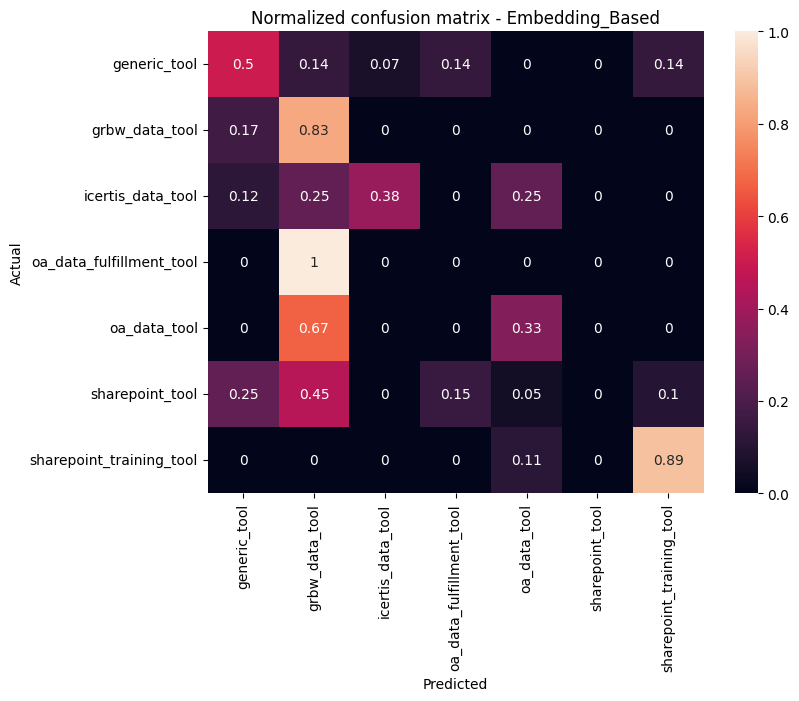


Confusion matrix - LLM_Router


,generic_tool,grbw_data_tool,icertis_data_tool,oa_data_fulfillment_tool,oa_data_tool,sharepoint_tool,sharepoint_training_tool
generic_tool,0.64,0.00,0.07,0.14,0.07,0.0,0.07
grbw_data_tool,0.75,0.17,0.00,0.00,0.08,0.0,0.00
icertis_data_tool,0.50,0.00,0.25,0.00,0.25,0.0,0.00
oa_data_fulfillment_tool,0.50,0.00,0.00,0.50,0.00,0.0,0.00
oa_data_tool,0.50,0.25,0.17,0.08,0.00,0.0,0.00
sharepoint_tool,0.57,0.05,0.10,0.29,0.00,0.0,0.00
sharepoint_training_tool,0.72,0.00,0.06,0.17,0.00,0.0,0.06


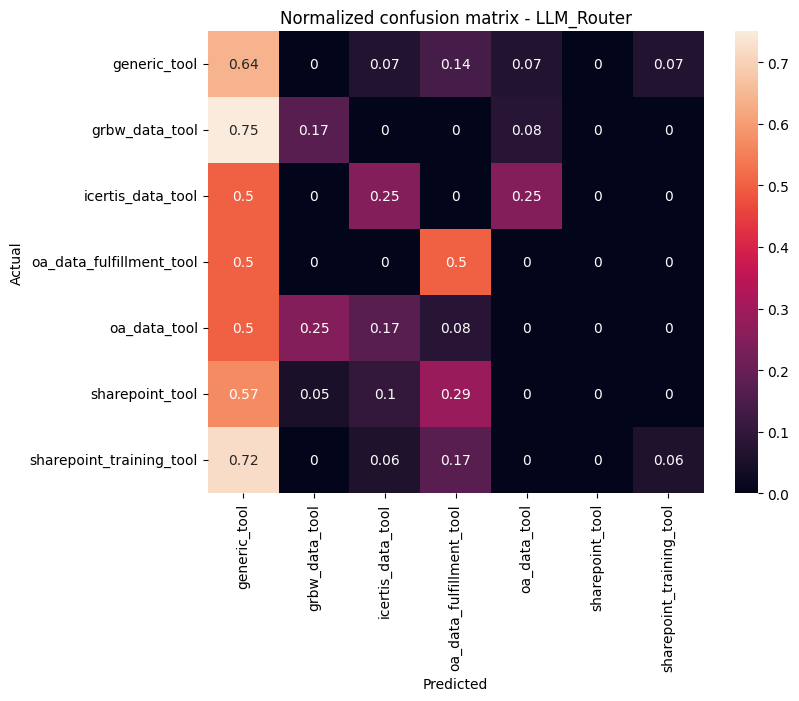

In [47]:
# ==================================================
# C5.1) Confusion matrix
# ==================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Select datast
df_eval = df_standard_all.query("dataset == 'baseline'")

# Strategies to compare
strategies = ["Embedding_Based", "LLM_Router"]

for strategy_name in strategies:
    df_strategy =  df_eval[df_eval["strategy"] == strategy_name].copy()

    # Get labels
    y_true = df_strategy["expected_tool"]
    y_pred = df_strategy["selected_tool"]

    # Compute confusion matrix
    labels = sorted(df_strategy["expected_tool"].dropna().unique())

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Convert to DataFrame for readability
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    # Normalize by row
    cm_normalized = cm_df.div(cm_df.sum(axis=1), axis=0).round(2)

    print(f"\nConfusion matrix - {strategy_name}")
    display(cm_normalized)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f"Normalized confusion matrix - {strategy_name}")
    plt.show()

In [55]:
print(df_standard_all.columns.tolist())

df_standard_all["selected_pool"].unique()

['version', 'run_type', 'architecture', 'query_id', 'query', 'dataset', 'strategy', 'selected_pool', 'selected_tool', 'final_confidence', 'action', 'threshold', 'fallback_enabled', 'trace', 'pool_confidence', 'expected_tool', 'is_correct']


array(['unified', 'Unified', 'OperationalProcurementPool',
       'StrategicKnowledgePool'], dtype=object)

In [65]:
# ==================================================
# C5.2) Pool Analysis
# ==================================================

#1) Keep only split architecture
df_pool = df_standard_all.query("architecture == 'split'")

# 2) Map expected tool -> expected pool
POOL_MAP = {
    "oa_data_tool": "OprationalProcurementPool",
    "oa_data_fullfilment_tool": "OprationalProcurementPool",
    "grbw_data_tool": "OprationalProcurementPool",
    "icertis_data_tool": "StrategicKnowledgePool",
    "sharepoint_tool": "StrategicKnowledgePool",
    "sharepoint_training_tool": "StrategicKnowledgePool",
    "generic_tool": "StrategicKnowledgePool"
}

df_pool["expected_pool"] = df_pool["expected_tool"].map(POOL_MAP)

# 3) Check if selected pool is correct
df_pool["is_pool_correct"] = df_pool["selected_pool"] == df_pool["expected_pool"]

# 4) Overall pool accuracy
pool_accuracy = df_pool["is_pool_correct"].mean()

# 5) Accuracy depending on pool correctness
tool_acc_when_pool_correct = df_pool[df_pool["is_pool_correct"]]["is_correct"].mean()
tool_acc_when_pool_wrong = df_pool[~df_pool["is_pool_correct"]]["is_correct"].mean()
# 4) Pool size
def pool_size(row):
    if isinstance(row["selected_pool"], list):
        return len(row["selected_pool"])
    return 0

df_pool["pool_size"] = df_pool.apply(pool_size, axis=1)
avg_pool_size = df_pool["pool_size"].mean()


# 5) Split analysis by startegy

results = (
    df_pool
    .groupby(["strategy"])
    .agg(
        pool_accuracy=("is_pool_correct", "mean"),
        tool_acc_when_pool_correct=("is_correct", "mean"),
        tool_acc_when_pool_wrong=("is_correct", "mean"),
    )
    .reset_index()
)

# Round
results = results.round(3)

print("Pool analysis by strategy:")
display(results)

Pool analysis by strategy:


/tmp/ipykernel_1760/208717420.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pool["expected_pool"] = df_pool["expected_tool"].map(POOL_MAP)
/tmp/ipykernel_1760/208717420.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pool["is_pool_correct"] = df_pool["selected_pool"] == df_pool["expected_pool"]
/tmp/ipykernel_1760/208717420.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

,strategy,pool_accuracy,tool_acc_when_pool_correct,tool_acc_when_pool_wrong
0,Embedding_Based,0.297,0.269,0.269
1,Hybrid,0.408,0.214,0.214
2,LLM_Router,0.408,0.214,0.214


In [70]:
# Matrix view
for strategy_name in ["Embedding_Based", "LLM_Router"]:
    df_strategy =  df_pool[df_pool["strategy"] == strategy_name]

    pool_matrix = pd.crosstab(
        df_strategy["expected_pool"],
        df_strategy["selected_pool"], normalize="index").round(2)

    print(f"\nPool confusion matrix - {strategy_name}")
    display(pool_matrix)


Pool confusion matrix - Embedding_Based


selected_pool,OperationalProcurementPool,StrategicKnowledgePool
expected_pool,,
OprationalProcurementPool,0.90,0.10
StrategicKnowledgePool,0.52,0.48



Pool confusion matrix - LLM_Router


selected_pool,OperationalProcurementPool,StrategicKnowledgePool
expected_pool,,
OprationalProcurementPool,0.38,0.62
StrategicKnowledgePool,0.34,0.66


In [88]:
# ==================================================
# D1) Experiment htreshold
# ==================================================

df_experiment_all["fallback_enabled"] = df_experiment_all["experiment_name"].apply(
    lambda x: "no_fallback" not in x if isinstance(x, str) else False
)

df_treshold_clean = df_experiment_all[df_experiment_all["fallback_enabled"] == False]
exp_treshold = (df_treshold_clean
                .groupby(["architecture", "strategy", "threshold"])
                .agg(
                    accuracy=("is_correct", "mean"),
                    avg_confidence=("final_confidence", "mean"),
                    n_queries=("query_id", "count")
                    )
                .reset_index()
                )
# Sort
exp_treshold = exp_treshold.sort_values(by=["architecture", "strategy", "threshold"]).reset_index(drop=True)

print("Experiment threshold:")
display(exp_treshold.round(3))

Experiment threshold:


,architecture,strategy,threshold,accuracy,avg_confidence,n_queries
0,split,Embedding_Based,0.6,0.269,0.531,650
1,split,Embedding_Based,0.7,0.269,0.531,650
2,split,Embedding_Based,0.8,0.269,0.531,650
3,split,Hybrid,0.6,0.191,0.504,650
4,split,Hybrid,0.7,0.214,0.496,650
5,split,Hybrid,0.8,0.214,0.496,650
6,split,LLM_Router,0.6,0.214,0.496,650
7,split,LLM_Router,0.7,0.214,0.496,650
8,split,LLM_Router,0.8,0.214,0.496,650
9,unified,Embedding_Based,0.6,0.346,0.544,650


In [96]:
# ==================================================
# D2) Experiment fallback
# ==================================================

df_experiment_all["fallback_enabled"] = df_experiment_all["experiment_name"].apply(
    lambda x: "no_fallback" not in x if isinstance(x, str) else False
)
#Only keep treshold 0.8
df_treshold_clean = df_experiment_all[df_experiment_all["threshold"] == 0.8]


exp_treshold = (df_treshold_clean
                .groupby(["architecture", "strategy", "fallback_enabled"])
                .agg(
                    accuracy=("is_correct", "mean"),
                    avg_confidence=("final_confidence", "mean"),
                    n_queries=("query_id", "count")
                    )
                .reset_index()
                )
# Sort
exp_treshold = exp_treshold.sort_values(by=["architecture", "strategy", "fallback_enabled"]).reset_index(drop=True)

print("Experiment threshold:")
display(exp_treshold.round(3))

Experiment threshold:


,architecture,strategy,fallback_enabled,accuracy,avg_confidence,n_queries
0,split,Embedding_Based,False,0.269,0.531,650
1,split,Embedding_Based,True,0.269,0.531,650
2,split,Hybrid,False,0.214,0.496,650
3,split,Hybrid,True,0.214,0.496,650
4,split,LLM_Router,False,0.214,0.496,650
5,split,LLM_Router,True,0.214,0.496,650
6,unified,Embedding_Based,False,0.346,0.544,650
7,unified,Embedding_Based,True,0.346,0.544,650
8,unified,Hybrid,False,0.134,0.416,650
9,unified,Hybrid,True,0.134,0.416,650
